In [16]:
from xgboost import XGBRegressor

from sklearn.metrics import (
r2_score,
mean_absolute_error,
mean_squared_error
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

df = pd.read_csv("data/processed/delhi_featured.csv")

In [5]:
features = [

'pm25',
'pm10',
'no2',
'so2',
'co',
'o3',

'temperature',
'humidity',
'wind_speed',
'visibility',

'aqi_lag1',
'aqi_lag3',
'aqi_lag7',

'pm25_roll_mean',
'pm25_roll_std',

'pm10_roll_mean',
'pm10_roll_std',

'season_encoded',

'pm_ratio',

'wind_humidity'

]

X = df[features]
y = df['aqi']

In [7]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(98196, 20)
(24549, 20)


In [8]:
from xgboost import XGBRegressor

xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=8,

    random_state=42

)

In [9]:
xgb.fit(

    X_train,

    y_train

)

print("Model Trained")

Model Trained


In [10]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np


pred = xgb.predict(X_test)

r2 = r2_score(y_test, pred)

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))


print("R² :", r2)

print("MAE :", mae)

print("RMSE :", rmse)

R² : 0.9999831318855286
MAE : 0.4436267018318176
RMSE : 0.7344431744037265


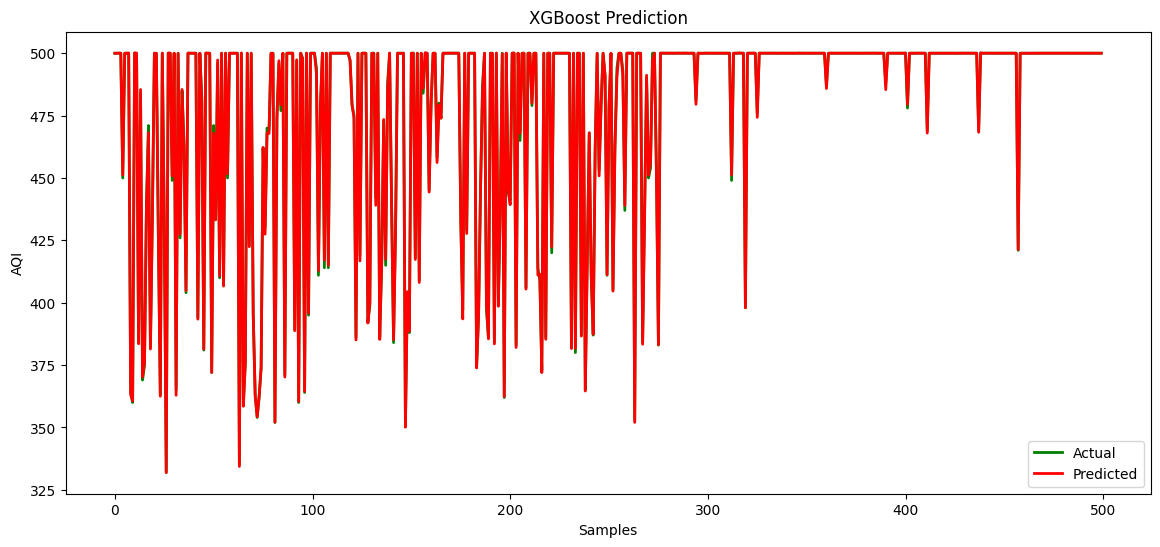

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:500],
    color='green',
    linewidth=2,
    label='Actual'
)

plt.plot(
    pred[:500],
    color='red',
    linewidth=2,
    label='Predicted'
)

plt.title("XGBoost Prediction")

plt.xlabel("Samples")
plt.ylabel("AQI")

plt.legend()

plt.show()

<Figure size 1000x800 with 0 Axes>

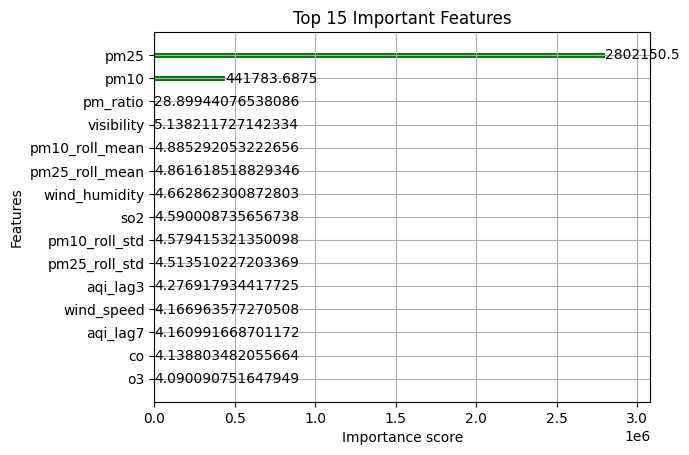

In [18]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))

plot_importance(
    xgb,
    max_num_features=15,
    importance_type='gain',
    color='green'
)

plt.title("Top 15 Important Features")

plt.show()

In [19]:
import joblib

joblib.dump(

xgb,

"models/xgboost.pkl"

)

print("✅ XGBoost Model Saved")

✅ XGBoost Model Saved
